# **Problem Statement**


---

#### **Business Context**  
Understanding customer personality and behavior is pivotal for businesses to enhance customer satisfaction and increase revenue. Segmentation based on a customer's personality, demographics, and purchasing behavior allows companies to create tailored marketing campaigns, improve customer retention, and optimize product offerings.  

A leading retail company with a rapidly growing customer base seeks to gain deeper insights into their customers' profiles. The company recognizes that understanding customer personalities, lifestyles, and purchasing habits can unlock significant opportunities for personalizing marketing strategies and creating loyalty programs. These insights can help address critical business challenges, such as improving the effectiveness of marketing campaigns, identifying high-value customer groups, and fostering long-term relationships with customers.  

With the competition intensifying in the retail space, moving away from generic strategies to more targeted and personalized approaches is essential for sustaining a competitive edge.  

---

#### **Objective**  
In an effort to optimize marketing efficiency and enhance customer experience, the company has embarked on a mission to identify distinct customer segments. By understanding the characteristics, preferences, and behaviors of each group, the company aims to:  
1. Develop personalized marketing campaigns to increase conversion rates.  
2. Create effective retention strategies for high-value customers.  
3. Optimize resource allocation, such as inventory management, pricing strategies, and store layouts.  

As a data scientist tasked with this project, your responsibility is to analyze the given customer data, apply machine learning techniques to segment the customer base, and provide actionable insights into the characteristics of each segment.  

---

#### **Data Dictionary**  
The dataset includes historical data on customer demographics, personality traits, and purchasing behaviors. Key attributes are:  

1. **Customer Information**  
   - **ID:** Unique identifier for each customer.  
   - **Year_Birth:** Customer's year of birth.  
   - **Education:** Education level of the customer.  
   - **Marital_Status:** Marital status of the customer.  
   - **Income:** Yearly household income (in dollars).  
   - **Kidhome:** Number of children in the household.  
   - **Teenhome:** Number of teenagers in the household.  
   - **Dt_Customer:** Date when the customer enrolled with the company.  
   - **Recency:** Number of days since the customer’s last purchase.  
   - **Complain:** Whether the customer complained in the last 2 years (1 for yes, 0 for no).  

2. **Spending Information (Last 2 Years)**  
   - **MntWines:** Amount spent on wine.  
   - **MntFruits:** Amount spent on fruits.  
   - **MntMeatProducts:** Amount spent on meat.  
   - **MntFishProducts:** Amount spent on fish.  
   - **MntSweetProducts:** Amount spent on sweets.  
   - **MntGoldProds:** Amount spent on gold products.  

3. **Purchase and Campaign Interaction**  
   - **NumDealsPurchases:** Number of purchases made using a discount.  
   - **AcceptedCmp1:** Response to the 1st campaign (1 for yes, 0 for no).  
   - **AcceptedCmp2:** Response to the 2nd campaign (1 for yes, 0 for no).  
   - **AcceptedCmp3:** Response to the 3rd campaign (1 for yes, 0 for no).  
   - **AcceptedCmp4:** Response to the 4th campaign (1 for yes, 0 for no).  
   - **AcceptedCmp5:** Response to the 5th campaign (1 for yes, 0 for no).  
   - **Response:** Response to the last campaign (1 for yes, 0 for no).  

4. **Shopping Behavior**  
   - **NumWebPurchases:** Number of purchases made through the company’s website.  
   - **NumCatalogPurchases:** Number of purchases made using catalogs.  
   - **NumStorePurchases:** Number of purchases made directly in stores.  
   - **NumWebVisitsMonth:** Number of visits to the company’s website in the last month.  

# **Let's start coding!**

## **Importing necessary libraries**

In [ ]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist, pdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# to suppress warnings
import warnings

warnings.filterwarnings("ignore")

## **Loading the data**

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# loading data into a pandas dataframe
data = pd.read_csv("/content/drive/MyDrive/MIT Course/Unsupervised Learning/Project/Customer_Personality_Segmentation.csv", sep='\t')

## **Data Overview**

In [ ]:
#checking that data has loaded correctly
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [ ]:
#creating a copy of the dataset as to not chnage the original
df = data.copy()

In [ ]:
#checking the amount of data, there are 29 columns and 2240 rows.
df.shape

(2240, 29)

#### **Question 1**: What are the data types of all the columns?

In [ ]:
# Getting the column types and null count of each column.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

##### **Observations:**
*   All variables are numerical except for Education, Marital_Status and Dt_Customer which are categorical data.
*   Dt_Customer should be a date so we will change it accordingly.
*   Based on the Data Dictionary ID is a unique identifier - we can check if that is correct and then drop this column from our analysis.








In [ ]:
#changing Dt_Customer to a date
df.Dt_Customer = pd.to_datetime(df.Dt_Customer, format = "%d-%m-%Y")

In [ ]:
#Checking unique values in the dataset
df.nunique()

,0
ID,2240
Year_Birth,59
Education,5
Marital_Status,8
Income,1974
Kidhome,3
Teenhome,3
Dt_Customer,663
Recency,100
MntWines,776




*   We can see that ID is unique with 2240 unique values
*   Also Z_Revenue and Z_CostContact have only one unique value, on looking at the data dictionary, there is no information on these columns and it seems they do not provide any real information to the dataset. Best to drop.



In [ ]:
#dropping ID, Cost Contract and Revenue
df.drop(columns=["ID", "Z_CostContact", "Z_Revenue"], inplace=True)


#### **Question 2:** Check the statistical summary of the data. What is the average household income?

In [ ]:
# Checking the stats of each column, including categorical columns.
df.describe(include = 'all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Year_Birth,2240.0,NaN,NaN,NaN,1968.805804,1893.0,1959.0,1970.0,1977.0,1996.0,11.984069
Education,2240,5,Graduation,1127,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,2240,8,Married,864,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,2216.0,NaN,NaN,NaN,52247.251354,1730.0,35303.0,51381.5,68522.0,666666.0,25173.076661
Kidhome,2240.0,NaN,NaN,NaN,0.444196,0.0,0.0,0.0,1.0,2.0,0.538398
Teenhome,2240.0,NaN,NaN,NaN,0.50625,0.0,0.0,0.0,1.0,2.0,0.544538
Dt_Customer,2240,NaN,NaN,NaN,2013-07-10 10:01:42.857142784,2012-07-30 00:00:00,2013-01-16 00:00:00,2013-07-08 12:00:00,2013-12-30 06:00:00,2014-06-29 00:00:00,NaN
Recency,2240.0,NaN,NaN,NaN,49.109375,0.0,24.0,49.0,74.0,99.0,28.962453
MntWines,2240.0,NaN,NaN,NaN,303.935714,0.0,23.75,173.5,504.25,1493.0,336.597393
MntFruits,2240.0,NaN,NaN,NaN,26.302232,0.0,1.0,8.0,33.0,199.0,39.773434


##### **Observations:**


*   The average age of the customers is 56 (Rounding 1968.8 to 1969)
*   The majority of customers highest education level is graduated and are married.
*   **The avg household income is $52,247.25**
*   Only 25% of people have one or max 2 children at home. Similarly with Teens, only 25% have one or max 2 teens at home.
*   Customers on avg have visited the store 49 days ago.
*   Customers on avg spend the most money on wine, followed by meat.
*   Customers tend to buy directly in store (Avg 6 times in the last 2 years) in comparison to any other avenue, web is a close second (Avg 4 times in the last two years).
*   Customers on average purchase twice using a discount, the 4th campaign worked slightly better than the rest with a 7% response rate.









#### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method

In [ ]:
#hecking if any column has missing values
df.isnull().sum()

,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0
MntFruits,0


In [ ]:
#checking the data which has the null values to see if there are any reasons for the missing values
df[df.isnull().any(axis=1)]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
10,1983,Graduation,Married,NaN,1,0,2013-11-15,11,5,5,6,0,2,1,1,1,0,2,7,0,0,0,0,0,0,0
27,1986,Graduation,Single,NaN,1,0,2013-02-20,19,5,1,3,3,263,362,0,27,0,0,1,0,0,0,0,0,0,0
43,1959,PhD,Single,NaN,0,0,2013-11-05,80,81,11,50,3,2,39,1,1,3,4,2,0,0,0,0,0,0,0
48,1951,Graduation,Single,NaN,2,1,2014-01-01,96,48,5,48,6,10,7,3,2,1,4,6,0,0,0,0,0,0,0
58,1982,Graduation,Single,NaN,1,0,2013-06-17,57,11,3,22,2,2,6,2,2,0,3,6,0,0,0,0,0,0,0
71,1973,2n Cycle,Married,NaN,1,0,2012-09-14,25,25,3,43,17,4,17,3,3,0,3,8,0,0,0,0,0,0,0
90,1957,PhD,Married,NaN,2,1,2012-11-19,4,230,42,192,49,37,53,12,7,2,8,9,0,0,0,0,0,0,0
91,1957,Graduation,Single,NaN,1,1,2014-05-27,45,7,0,8,2,0,1,1,1,0,2,7,0,0,0,0,0,0,0
92,1973,Master,Together,NaN,0,0,2013-11-23,87,445,37,359,98,28,18,1,2,4,8,1,0,0,0,0,0,0,0
128,1961,PhD,Married,NaN,0,1,2013-07-11,23,352,0,27,10,0,15,3,6,1,7,6,0,0,0,0,0,0,0


In [ ]:
#checking the % of missing values
df.Income.value_counts(normalize = True, dropna = False)

,proportion
Income,
NaN,0.010714
7500.0,0.005357
35860.0,0.001786
18929.0,0.001339
37760.0,0.001339
...,...
33562.0,0.000446
57731.0,0.000446
73807.0,0.000446


##### **Observations:**


*   Income has 24 missing data points
*   On looking at the data, it doesnt seem like there is a reason for the missing value e.g. younger customer might not have a job etc. but age is very mixed and seems at random.
* As this is only 1% of the data, we can drop it instead of using mean etc.



In [ ]:
#dropping the null values
df = df.dropna()

In [ ]:
#checking the new shape of the data
df.shape

(2216, 26)

#### **Question 4**: Are there any duplicates in the data?

In [ ]:
#checking the amount of duplicates in the data
df.duplicated().sum()

np.int64(182)

In [ ]:
#dropping the duplicates
df=df[~df.duplicated()]

In [ ]:
#checking the new shape of the data
df.shape

(2034, 26)

##### **Observations:**


*   We want each row to represent only one person so dropping the 186 duplicated data as they do not add new information



## **Exploratory Data Analysis**

### Univariate Analysis

#### **Question 5:** Explore all the variables and provide observations on their distributions. (histograms and boxplots)

In [ ]:
# Function to plot a boxplot and a histogram along the same scale

def histogram_boxplot(data, feature, figsize = (15, 5), kde = False, bins = None):

    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows = 1, # have both graphs on the same row
        ncols = 2, # have 2 graphs per row
        sharex = True,  # X-axis will be shared among all subplots
        figsize = figsize,
    )  # Creating the 2 subplots
    sns.boxplot(
        data = data, x = feature, ax = ax_box2, showmeans = True, color = "#EC5656"
    )  # Boxplot will be created and a triangle will indicate the mean value of the column
    ax_box2.set_title(f"Boxplot of {feature}", fontsize=12) #adding title to boxplot

    sns.histplot(
        data = data, x = feature, kde = kde, ax = ax_hist2, bins = bins
    ) if bins else sns.histplot(
        data = data, x = feature, kde = kde, ax = ax_hist2
    )  # creating histogram
    ax_hist2.set_title(f"Histogram of {feature}", fontsize=12) #setting the title

    ax_hist2.axvline(
        data[feature].mean(), color = "green", linestyle = "--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color = "black", linestyle = "-"
    )  # Add median to the histogram

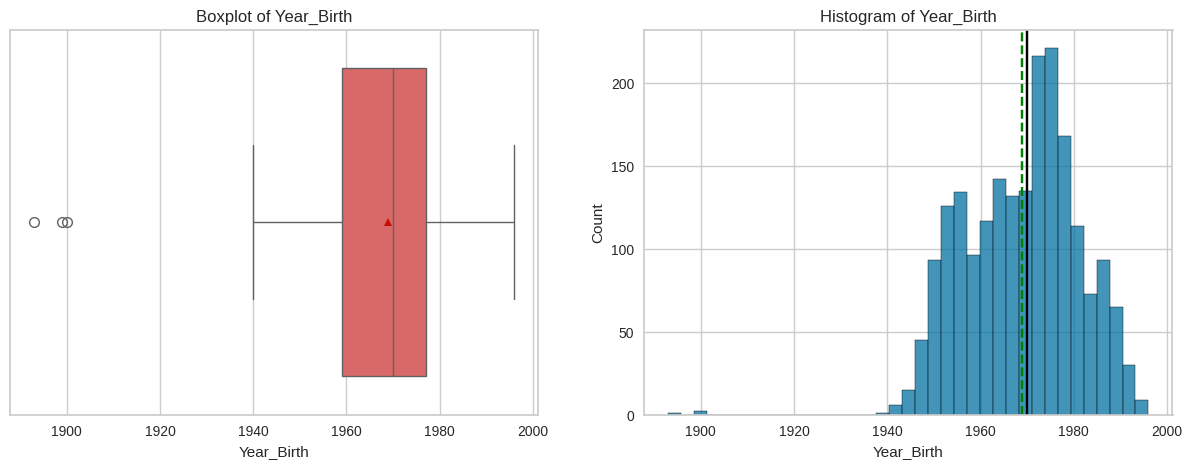

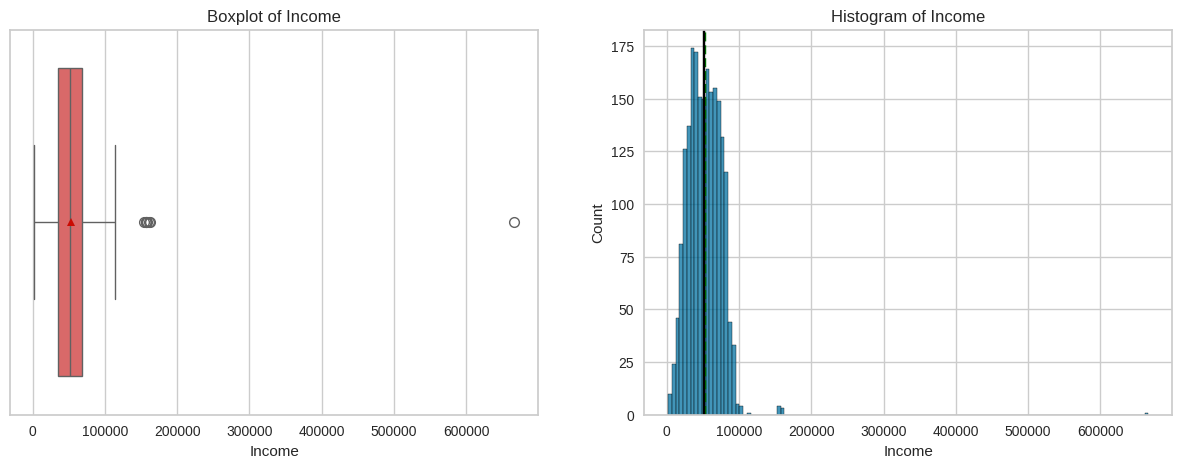

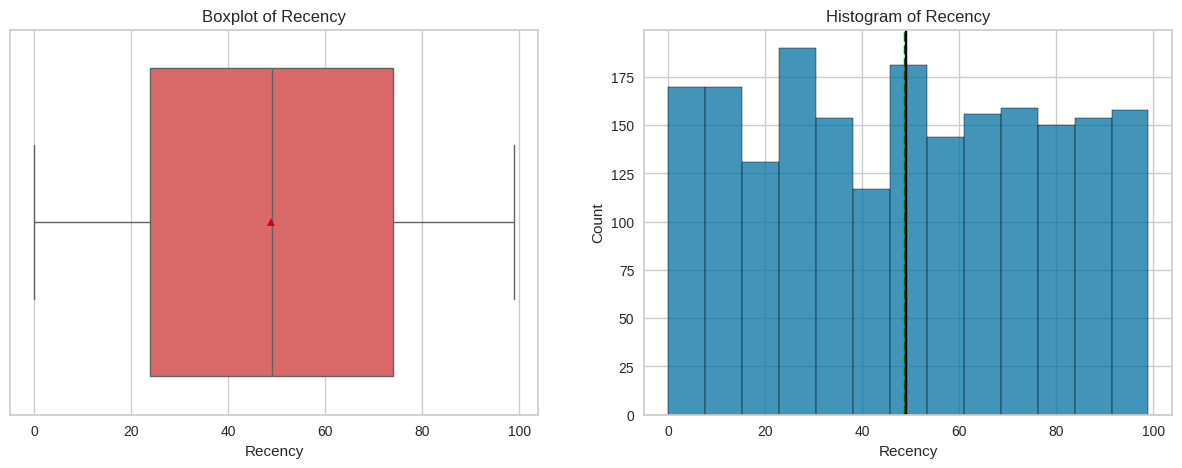

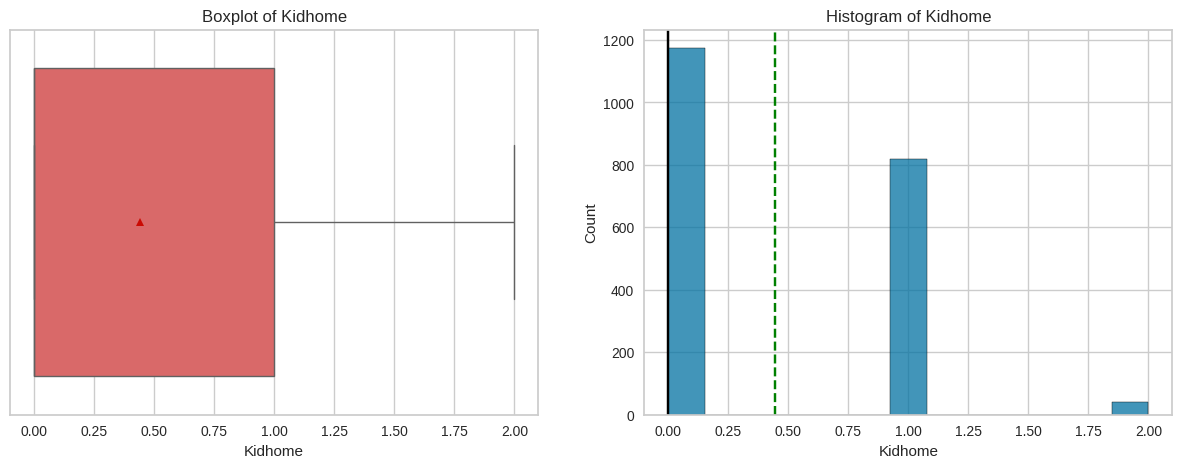

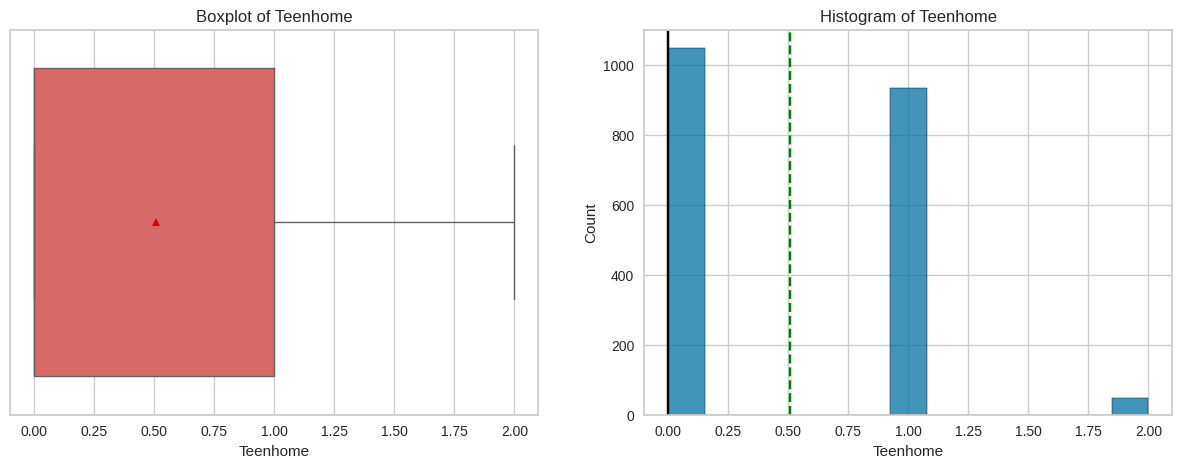

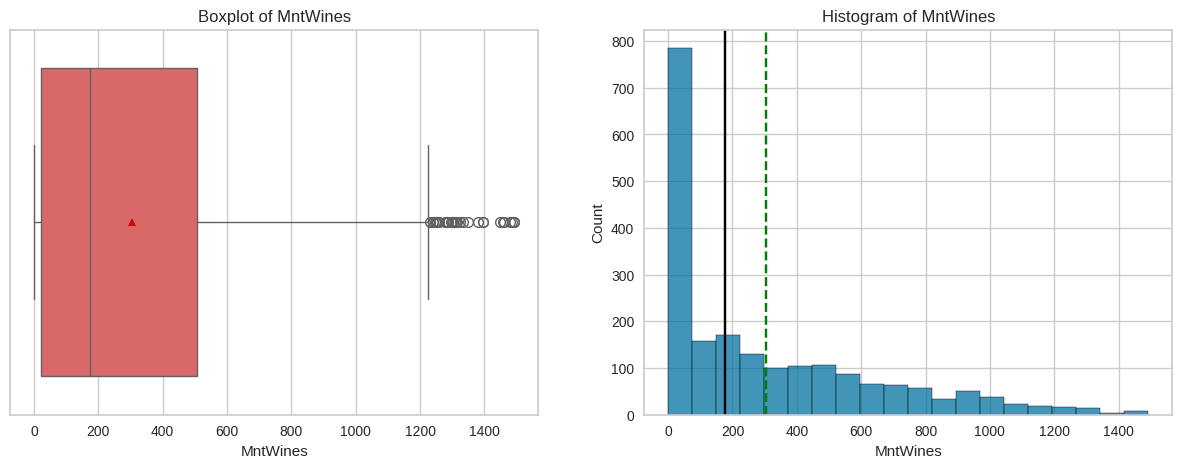

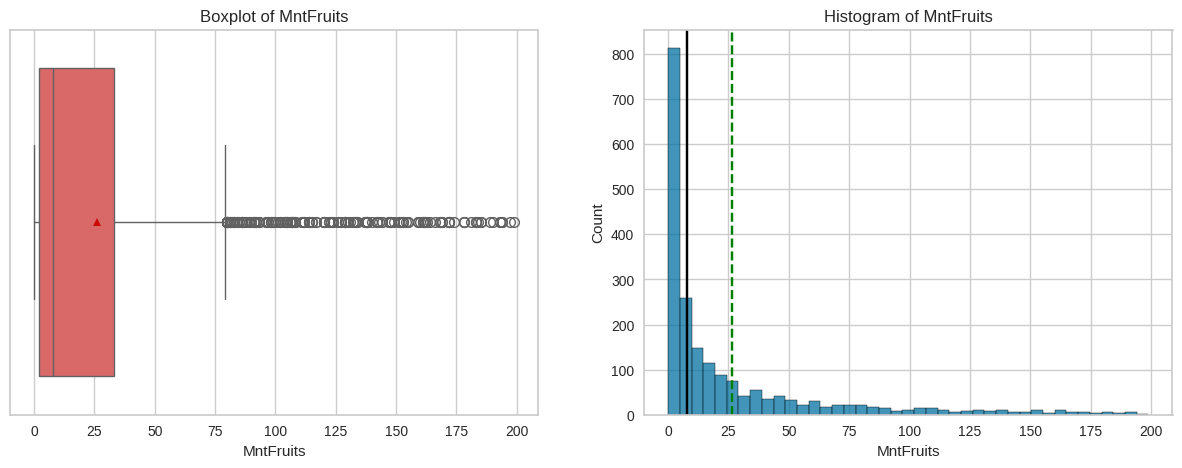

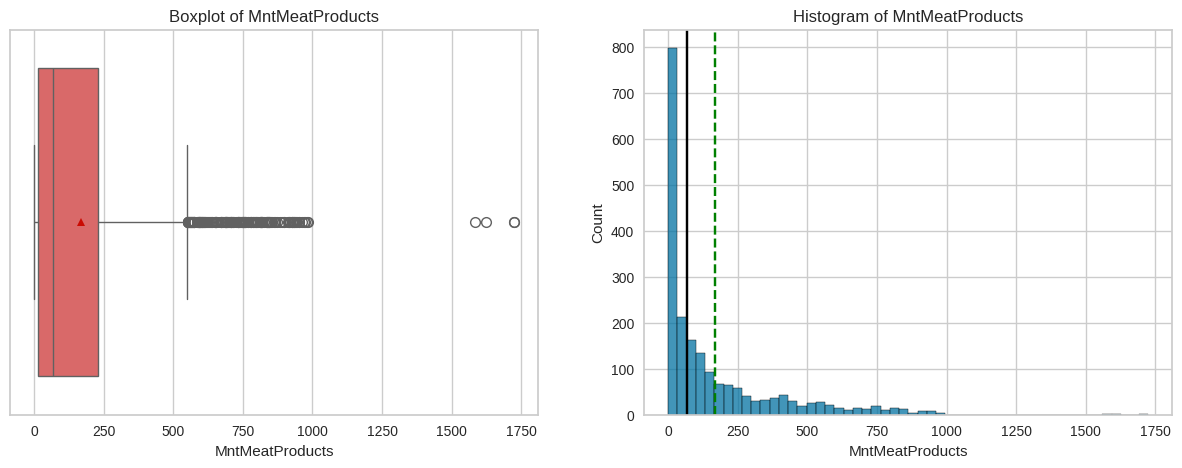

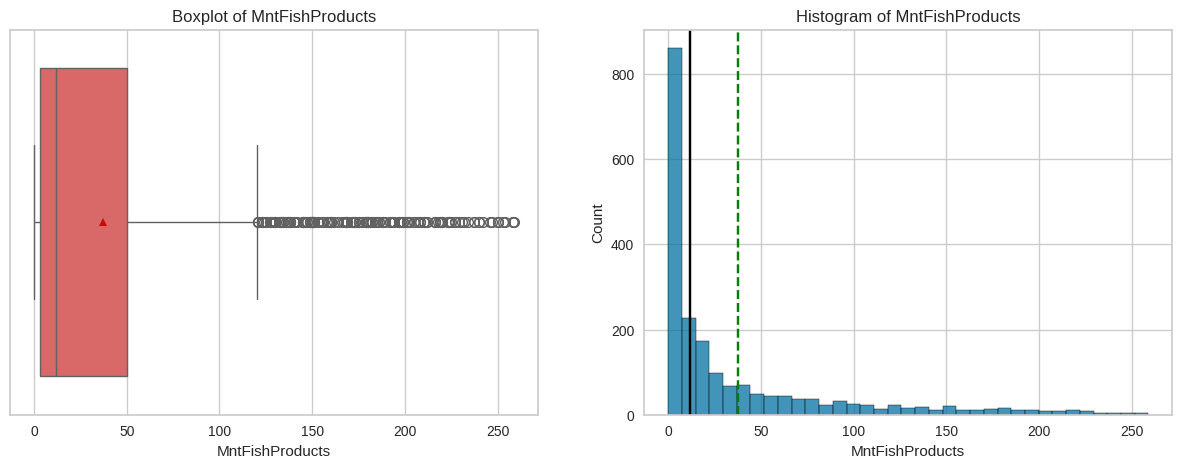

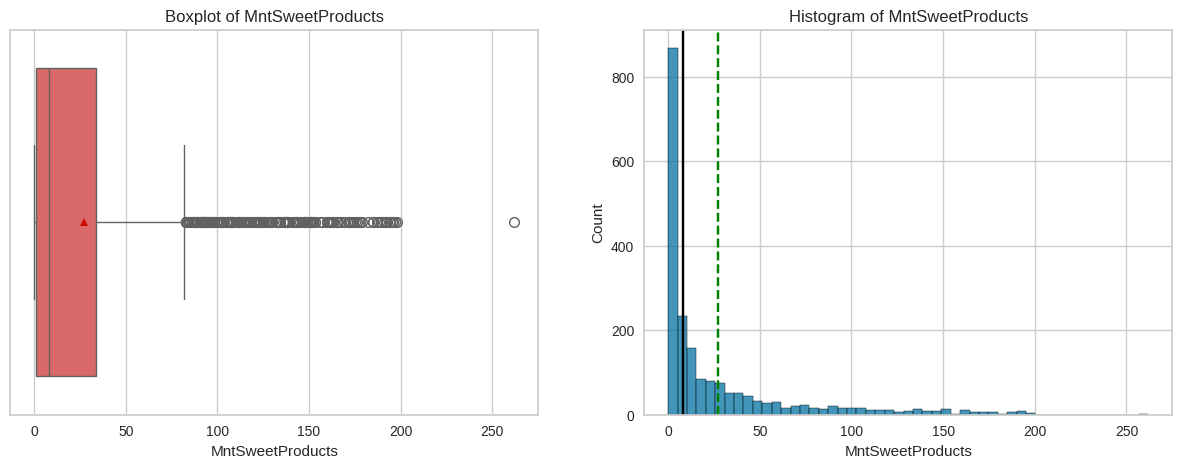

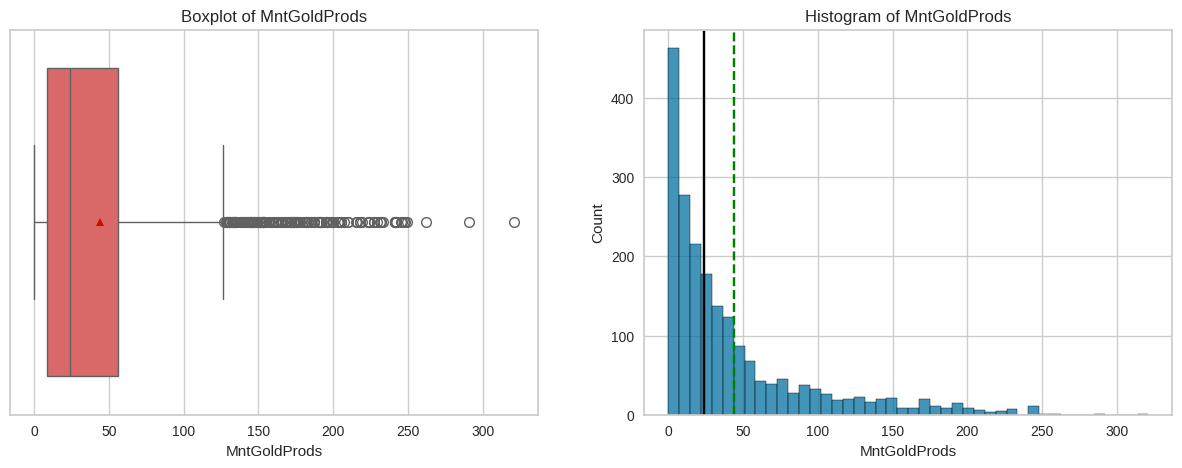

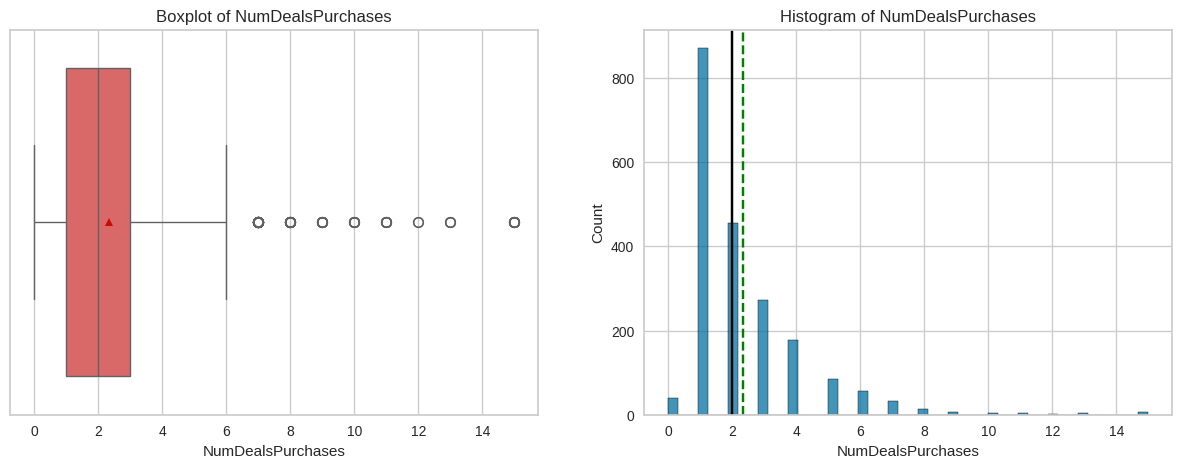

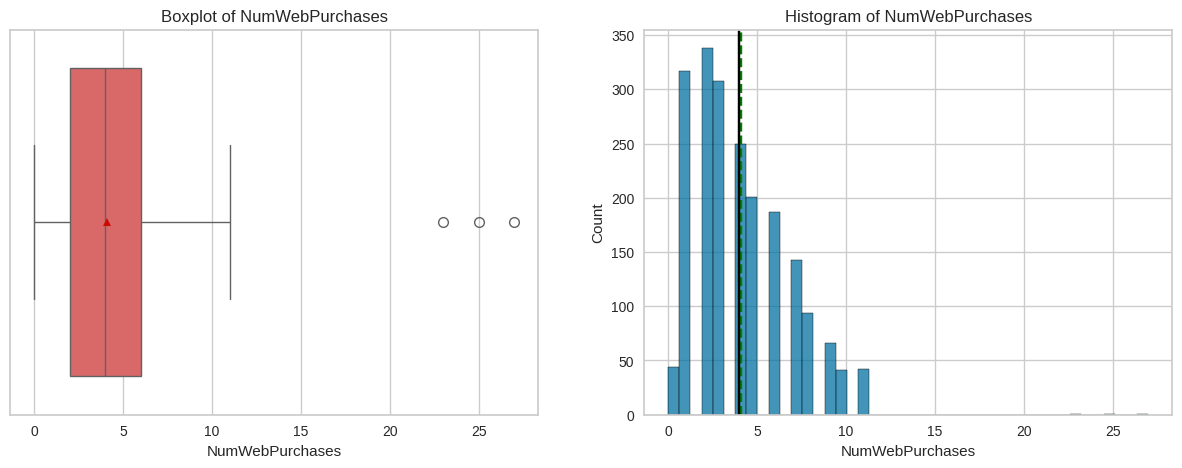

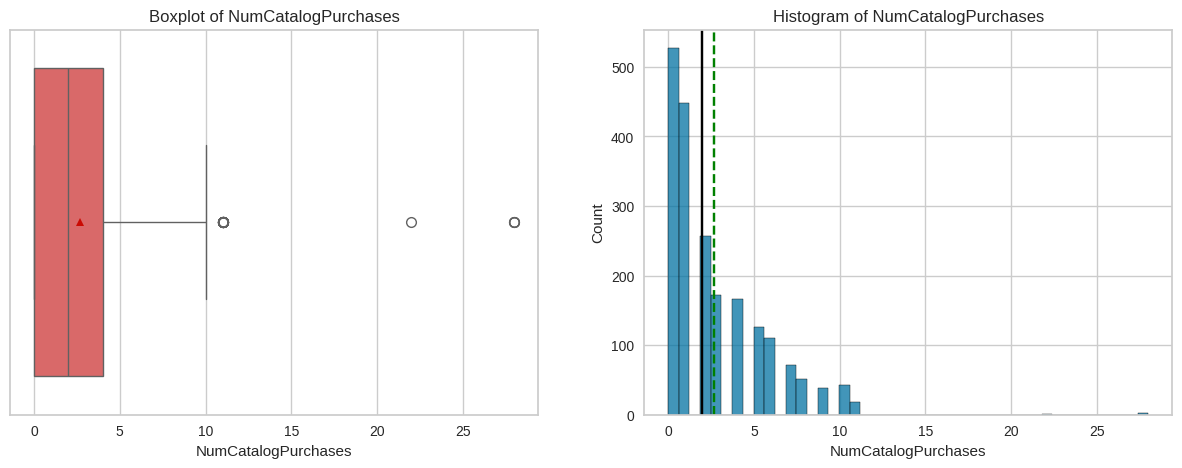

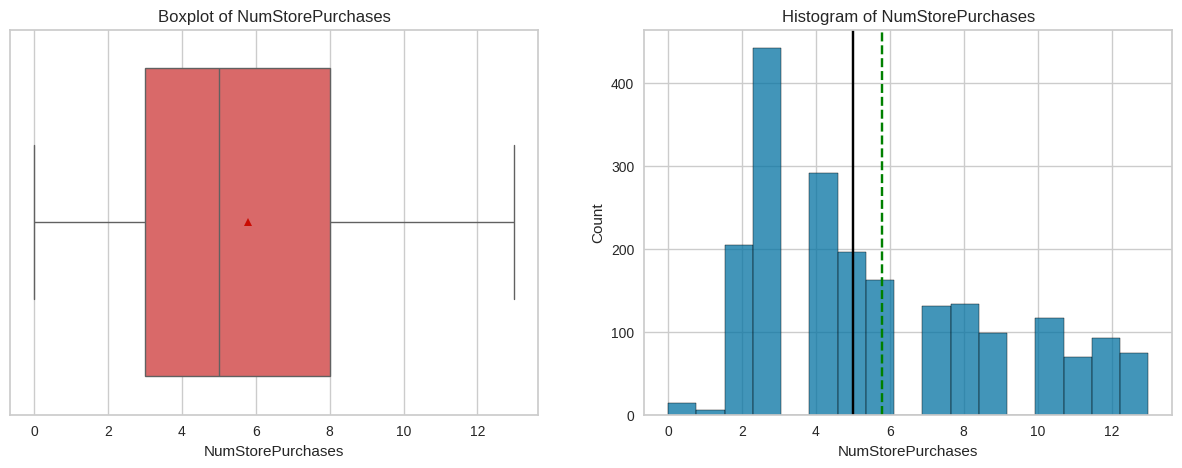

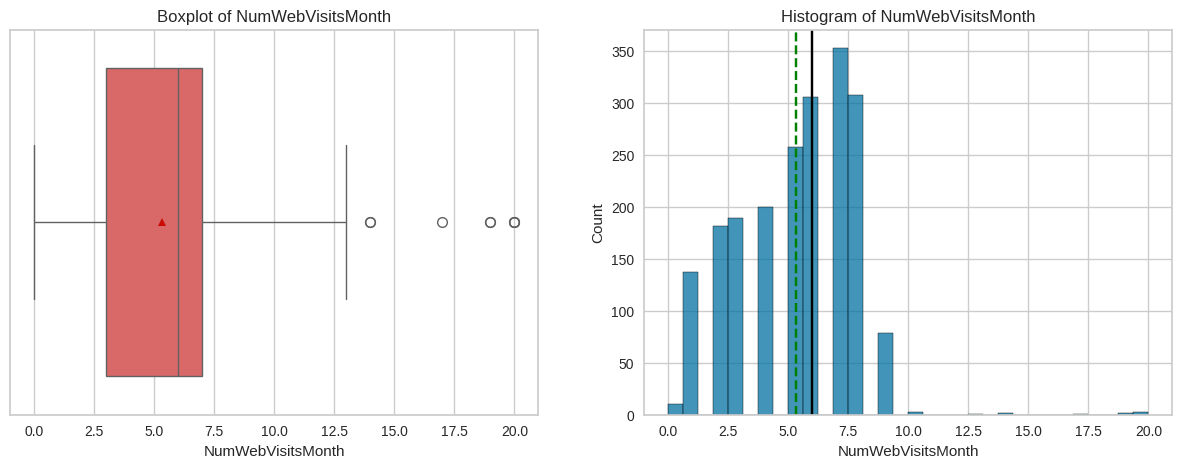

In [ ]:
NumColumns = ["Year_Birth", "Income", "Recency", "Kidhome", "Teenhome","MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds", "NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases", "NumWebVisitsMonth"]
for col in NumColumns:
    histogram_boxplot(df, col)

##### **Observations:**


*   Year_Birth is right skewed and with a few outliers with ages less than 1900, may need to look into this.
*   Income is righ skewed with a large outlier of around 700,000, this would make sense as e.g. a business owner or ceo could make this amount of money but we may need to look into this as it is such a large skew and kmeans does not handle  large outliers very well.
* Recency is approximately symmetrical, with the mean and median sitting around 50.
* All the other features are right-skewed with some outliers but all outliers would make sense.



*   The majority of customer have purchased just over twice from the store or the web. The least amout of purchase came from the catalog.
*   The majority of customers make around 60,000 and have no kids or teens at home.
* Customers spend the highest amount on wine with an IQR of around 100-550, followed by meat.




###Checking Outliers

In [ ]:
#checking Year_Birth
df[df["Year_Birth"] < 1940]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Labels




*   Lets cap age for people born in or after 1940




In [ ]:
df = df[df["Year_Birth"] >= 1940]

In [ ]:
#checking Income
df[df["Income"] > 200000]

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Labels



*   One extreme outlier could skew the data - lets cap the income to max 200,000



In [ ]:
df = df[df["Income"] < 200000]

##Histograms

In [ ]:
# Function to create labeled barplots


def labeled_barplot(data, feature, perc = False, n = None):

    total = len(data[feature])  # Length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize = (count + 1, 5))
    else:
        plt.figure(figsize = (n + 1, 5))

    plt.xticks(rotation = 90, fontsize = 15)
    ax = sns.countplot(
        data = data,
        x = feature,
        palette = "Paired",
        order = data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )                       # Percentage of each class of the category
        else:
            label = p.get_height()  # Count of each level of the category

        x = p.get_x() + p.get_width() / 2  # Width of the plot
        y = p.get_height()                 # Height of the plot

        ax.annotate(
            label,
            (x, y),
            ha = "center",
            va = "center",
            size = 12,
            xytext = (0, 5),
            textcoords = "offset points",
        )  # Annotate the percentage

    plt.show()  #

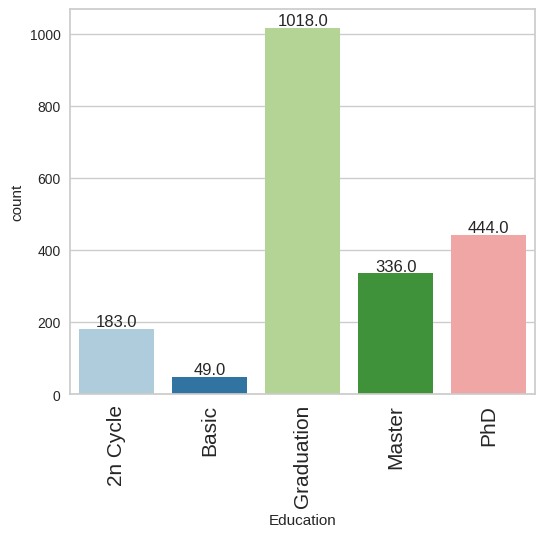

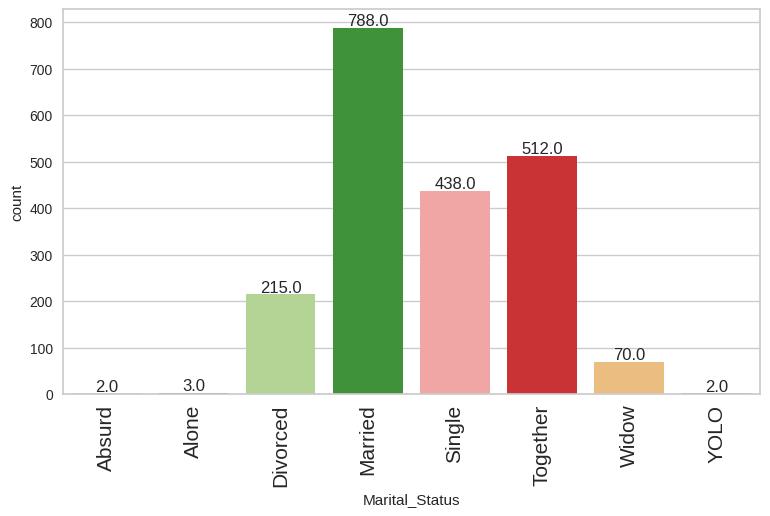

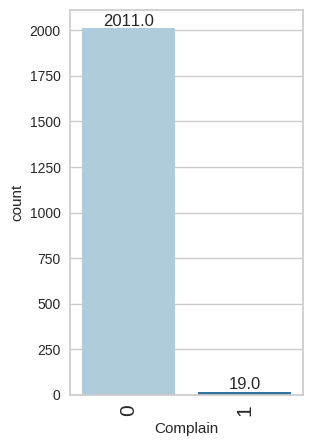

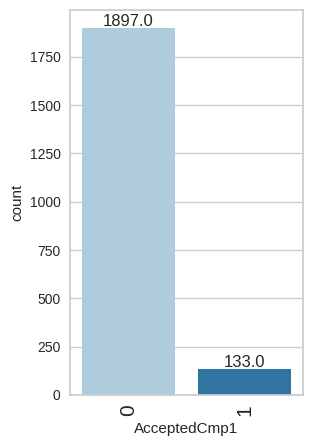

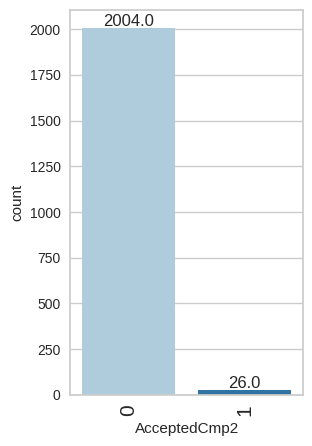

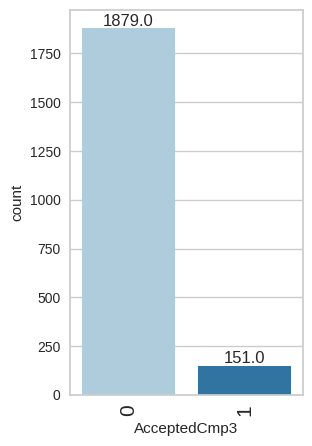

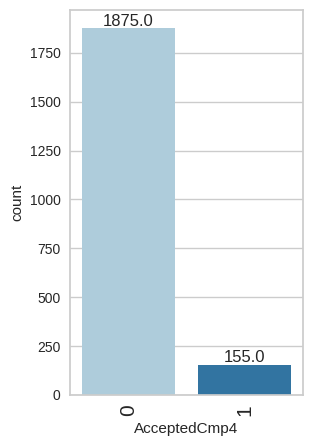

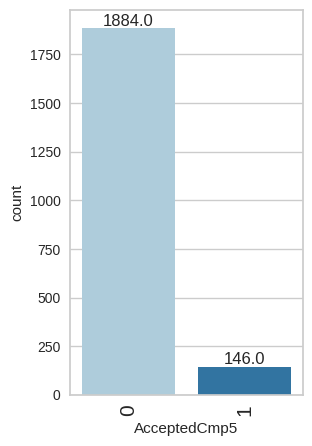

In [ ]:
columns = ["Education", "Marital_Status", "Complain", "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3","AcceptedCmp4", "AcceptedCmp5"]
for col in columns:
    labeled_barplot(df, col)

##### **Observations:**


*   Majority of people have graduated university followed by PHD, the customer base of the store seems to be very well educated. Tend to be more research driven buyers.
*   Majority of people are married or together. May be more interested in bundled offers e.g. "Dinner for two"
*   Very small quantity of people have responded to any campaigns held by the store suggesting current campaigns do not strongly influence behavior.










In [ ]:
#dropping campaign columns
df = df.drop(["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5"], axis=1)

#### **Question 6:** Perform multivariate analysis to explore the relationsips between the variables.

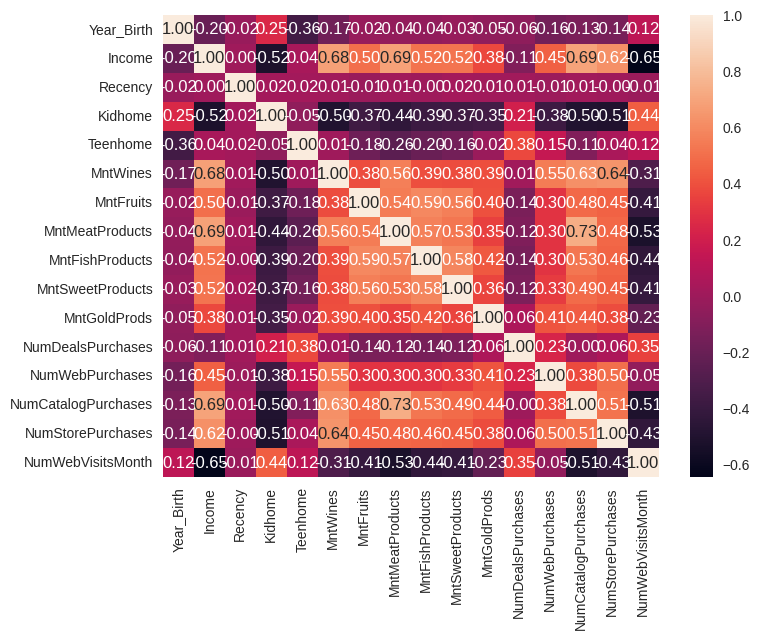

In [ ]:
#creating heatmap of numerical columns
plt.figure(figsize=(8,6))
sns.heatmap(df[NumColumns].corr(), annot=True, fmt='0.2f')
plt.show()

##### **Observations:**


*   Year_Birth and Recency do not have a strong correlation with any feature in this dataset which would suggest age or how recent someone has visited the shop is not a strong driver of behavior.
*   Families with Kids or Teens at home tend to have moderate negative correlations with spending on Meat, Fish, Wine which would suggest that they have less spare money to spend.
*   MntWine has a moderate to strong correlation with Meat, WebPurchased, CatelogPurchased and StorePurchased.
*   MntMeatProducts has a strong correlation with NumCatalogPurchased suggesting that customer who spend more on meat tend to also be more active catalog shoppers.
* Income has a strong positive correlation with NumStorePurchases and NumCatelogPurchased suggesting that high-income customers are not only more active in-store but also more engaged with catalogue shopping
* Income has a slight negative correlation with WebVistis which suggest that higher income customer tend to visit the webite less frequently.





## **K-means Clustering**

In [ ]:
#Scaling the data
scaler=StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[NumColumns]), columns=NumColumns)

In [ ]:
#copying the scaled data for later
df_scaled_copy = df_scaled.copy(deep = True)

#### **Question 7** : Select the appropriate number of clusters using the elbow Plot. What do you think is the appropriate number of clusters?

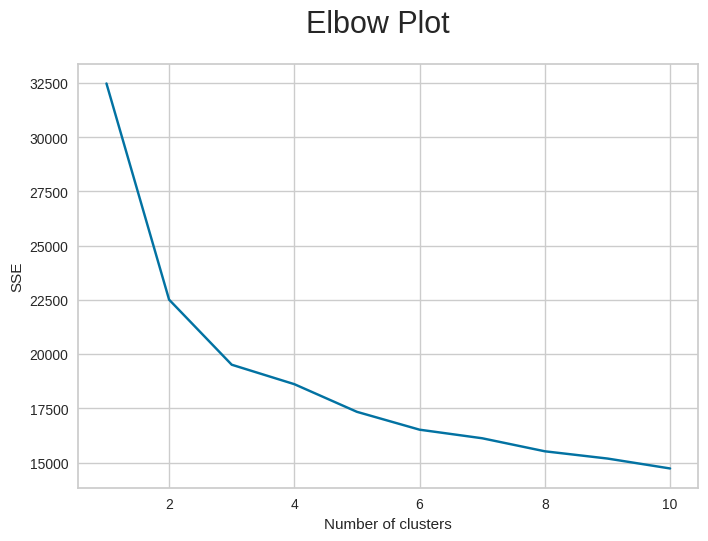

In [ ]:
# Empty dictionary to store the SSE for each value of K
sse = {}

# Iterate for a range of Ks and fit the scaled data to the algorithm.
# Use inertia attribute from the clustering object and store the inertia value for that K
for k in range(1, 11):
    kmeans = KMeans(n_clusters = k, random_state = 1).fit(df_scaled)

    sse[k] = kmeans.inertia_


plt.figure()
plt.suptitle("Elbow Plot", fontsize=22)
plt.plot(list(sse.keys()), list(sse.values()), 'bx-')
plt.xlabel("Number of clusters")
plt.ylabel("SSE")
plt.show()

##### **Observations:**

*   We can see from the plot that there is a consistent dip from 2 to 10. There doesn't seem to be a clear elbow here.



#### **Question 8** : finalize appropriate number of clusters by checking the silhoutte score as well. Is the answer different from the elbow plot?

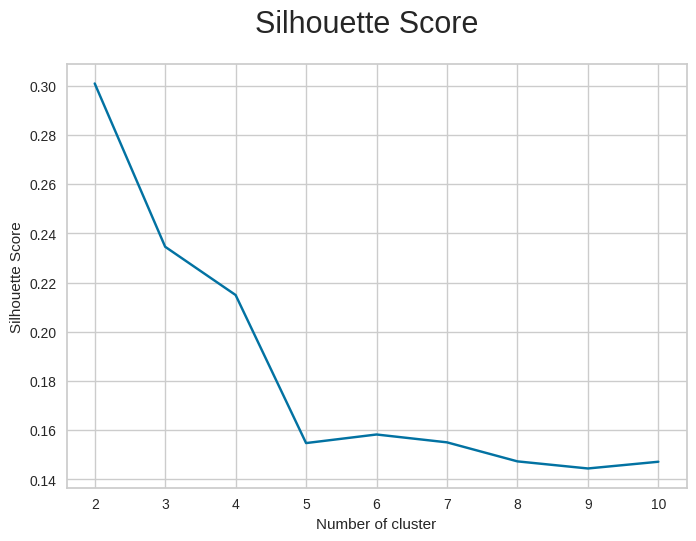

In [ ]:
# Empty dictionary to store the Silhouette score for each value of K
sc = {}

# Iterate for a range of Ks and fit the scaled data to the algorithm. Store the Silhouette score for that K
for k in range(2, 11):
    kmeans = KMeans(n_clusters = k, random_state = 1).fit(df_scaled)

    labels = kmeans.predict(df_scaled)

    sc[k] = silhouette_score(df_scaled, labels)


plt.figure()
plt.suptitle("Silhouette Score", fontsize=22)
plt.plot(list(sc.keys()), list(sc.values()), 'bx-')
plt.xlabel("Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

##### **Observations:**


*   The Silhouette Score is largest at 2 so that should be the number of clusters we use.




#### **Question 9**: Do a final fit with the appropriate number of clusters. How much total time does it take for the model to fit the data?

In [ ]:
means = KMeans(n_clusters=2, random_state=1)
means.fit(df_scaled)

#Adding predicted labels to the original data and scaled data
df_scaled_copy['Labels'] = means.predict(df_scaled)
df['Labels'] = means.predict(df_scaled)

In [ ]:
df.Labels.value_counts()

,count
Labels,
0,1177
1,853


##### **Observations:**


*   It takes less than a second to fit the data.



## **Cluster Profiling and Comparison**

#### **Question 10**: Perform cluster profiling using boxplots for the K-Means algorithm. Analyze key characteristics of each cluster and provide detailed observations.

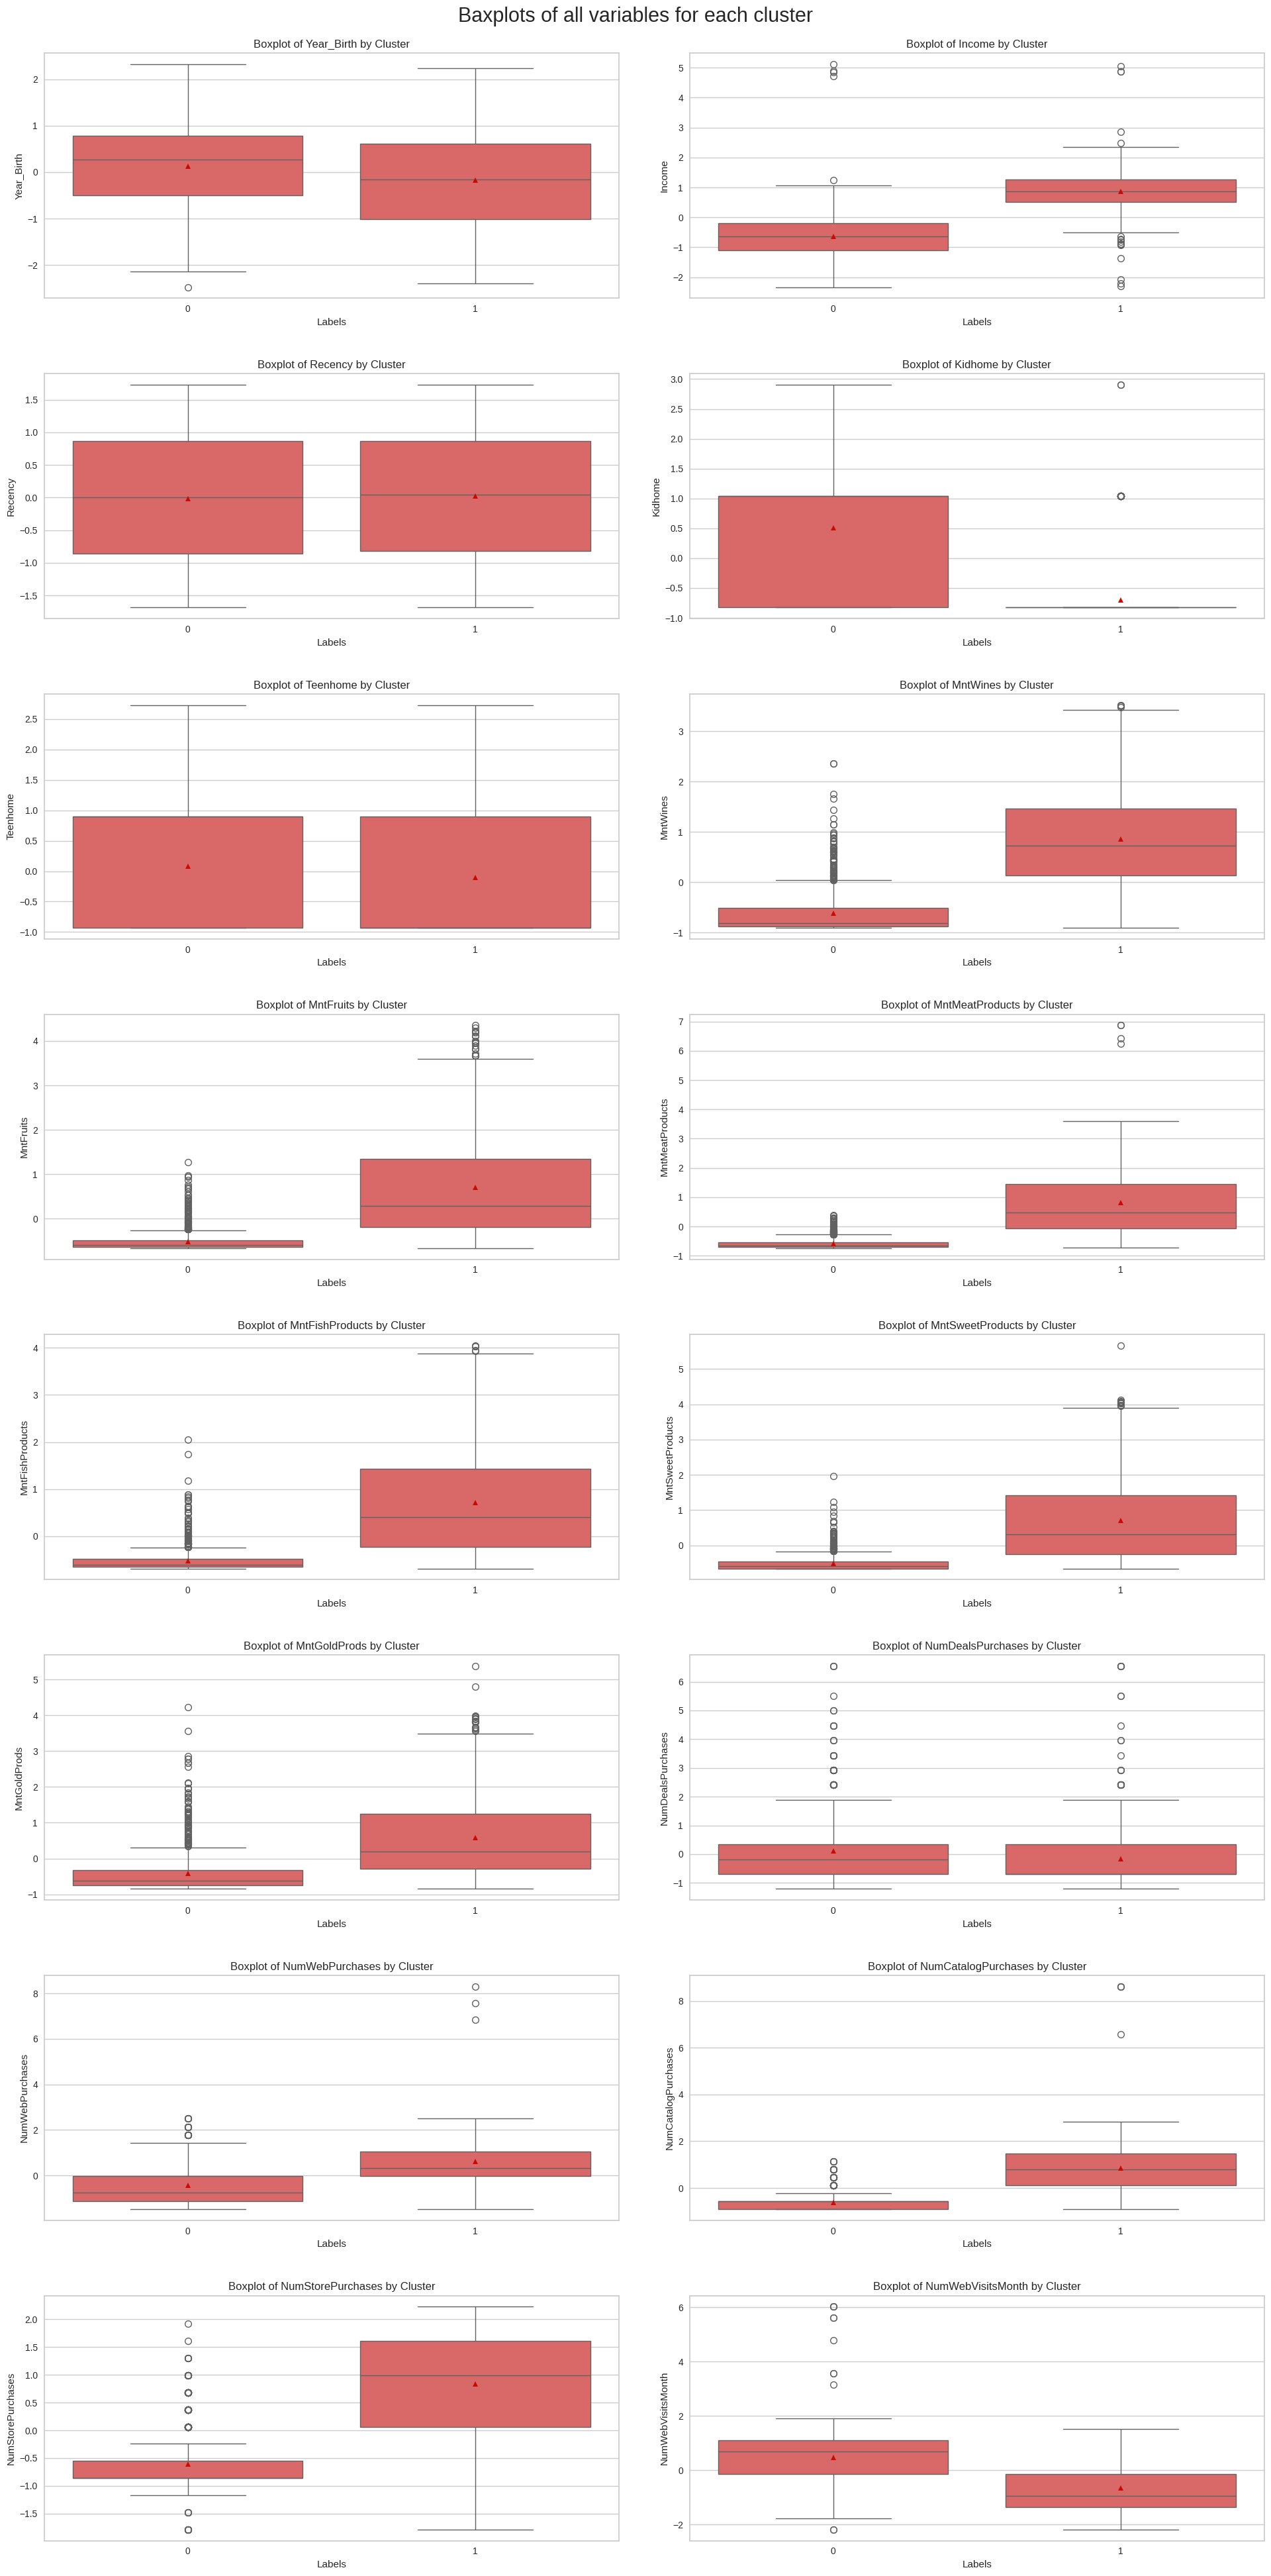

In [ ]:
plt.figure(figsize=(20, 40))
plt.suptitle("Baxplots of all variables for each cluster", fontsize=22)

for i, variable in enumerate(NumColumns):
    plt.subplot(8, 2, i + 1)  # use i + 1 as subplot index
    sns.boxplot(x='Labels', y=variable, data=df_scaled_copy, color="#EC5656", showmeans=True)
    plt.title(f"Boxplot of {variable} by Cluster")

plt.tight_layout(pad = 3)  # leave space for suptitle
plt.show()



##### **Observations:**


*   Cluster 0: lower income customers who have kids. They tend to spend less on all areas including; Wine, Fish, Meat, Sweets and Gold Products. They spend more time browsing the web shop but not actually buying. Slightly older.
*   Cluster 1: Higher income customers that do not tend to have young kids.  They spend accross all areas of the store fairly equally and tend to purchase from the shop quite often.


#### **Question 11**: Perform cluster profiling on the data using a barplot for the K-Means algorithm. Provide insights and key observations for each cluster based on the visual analysis.

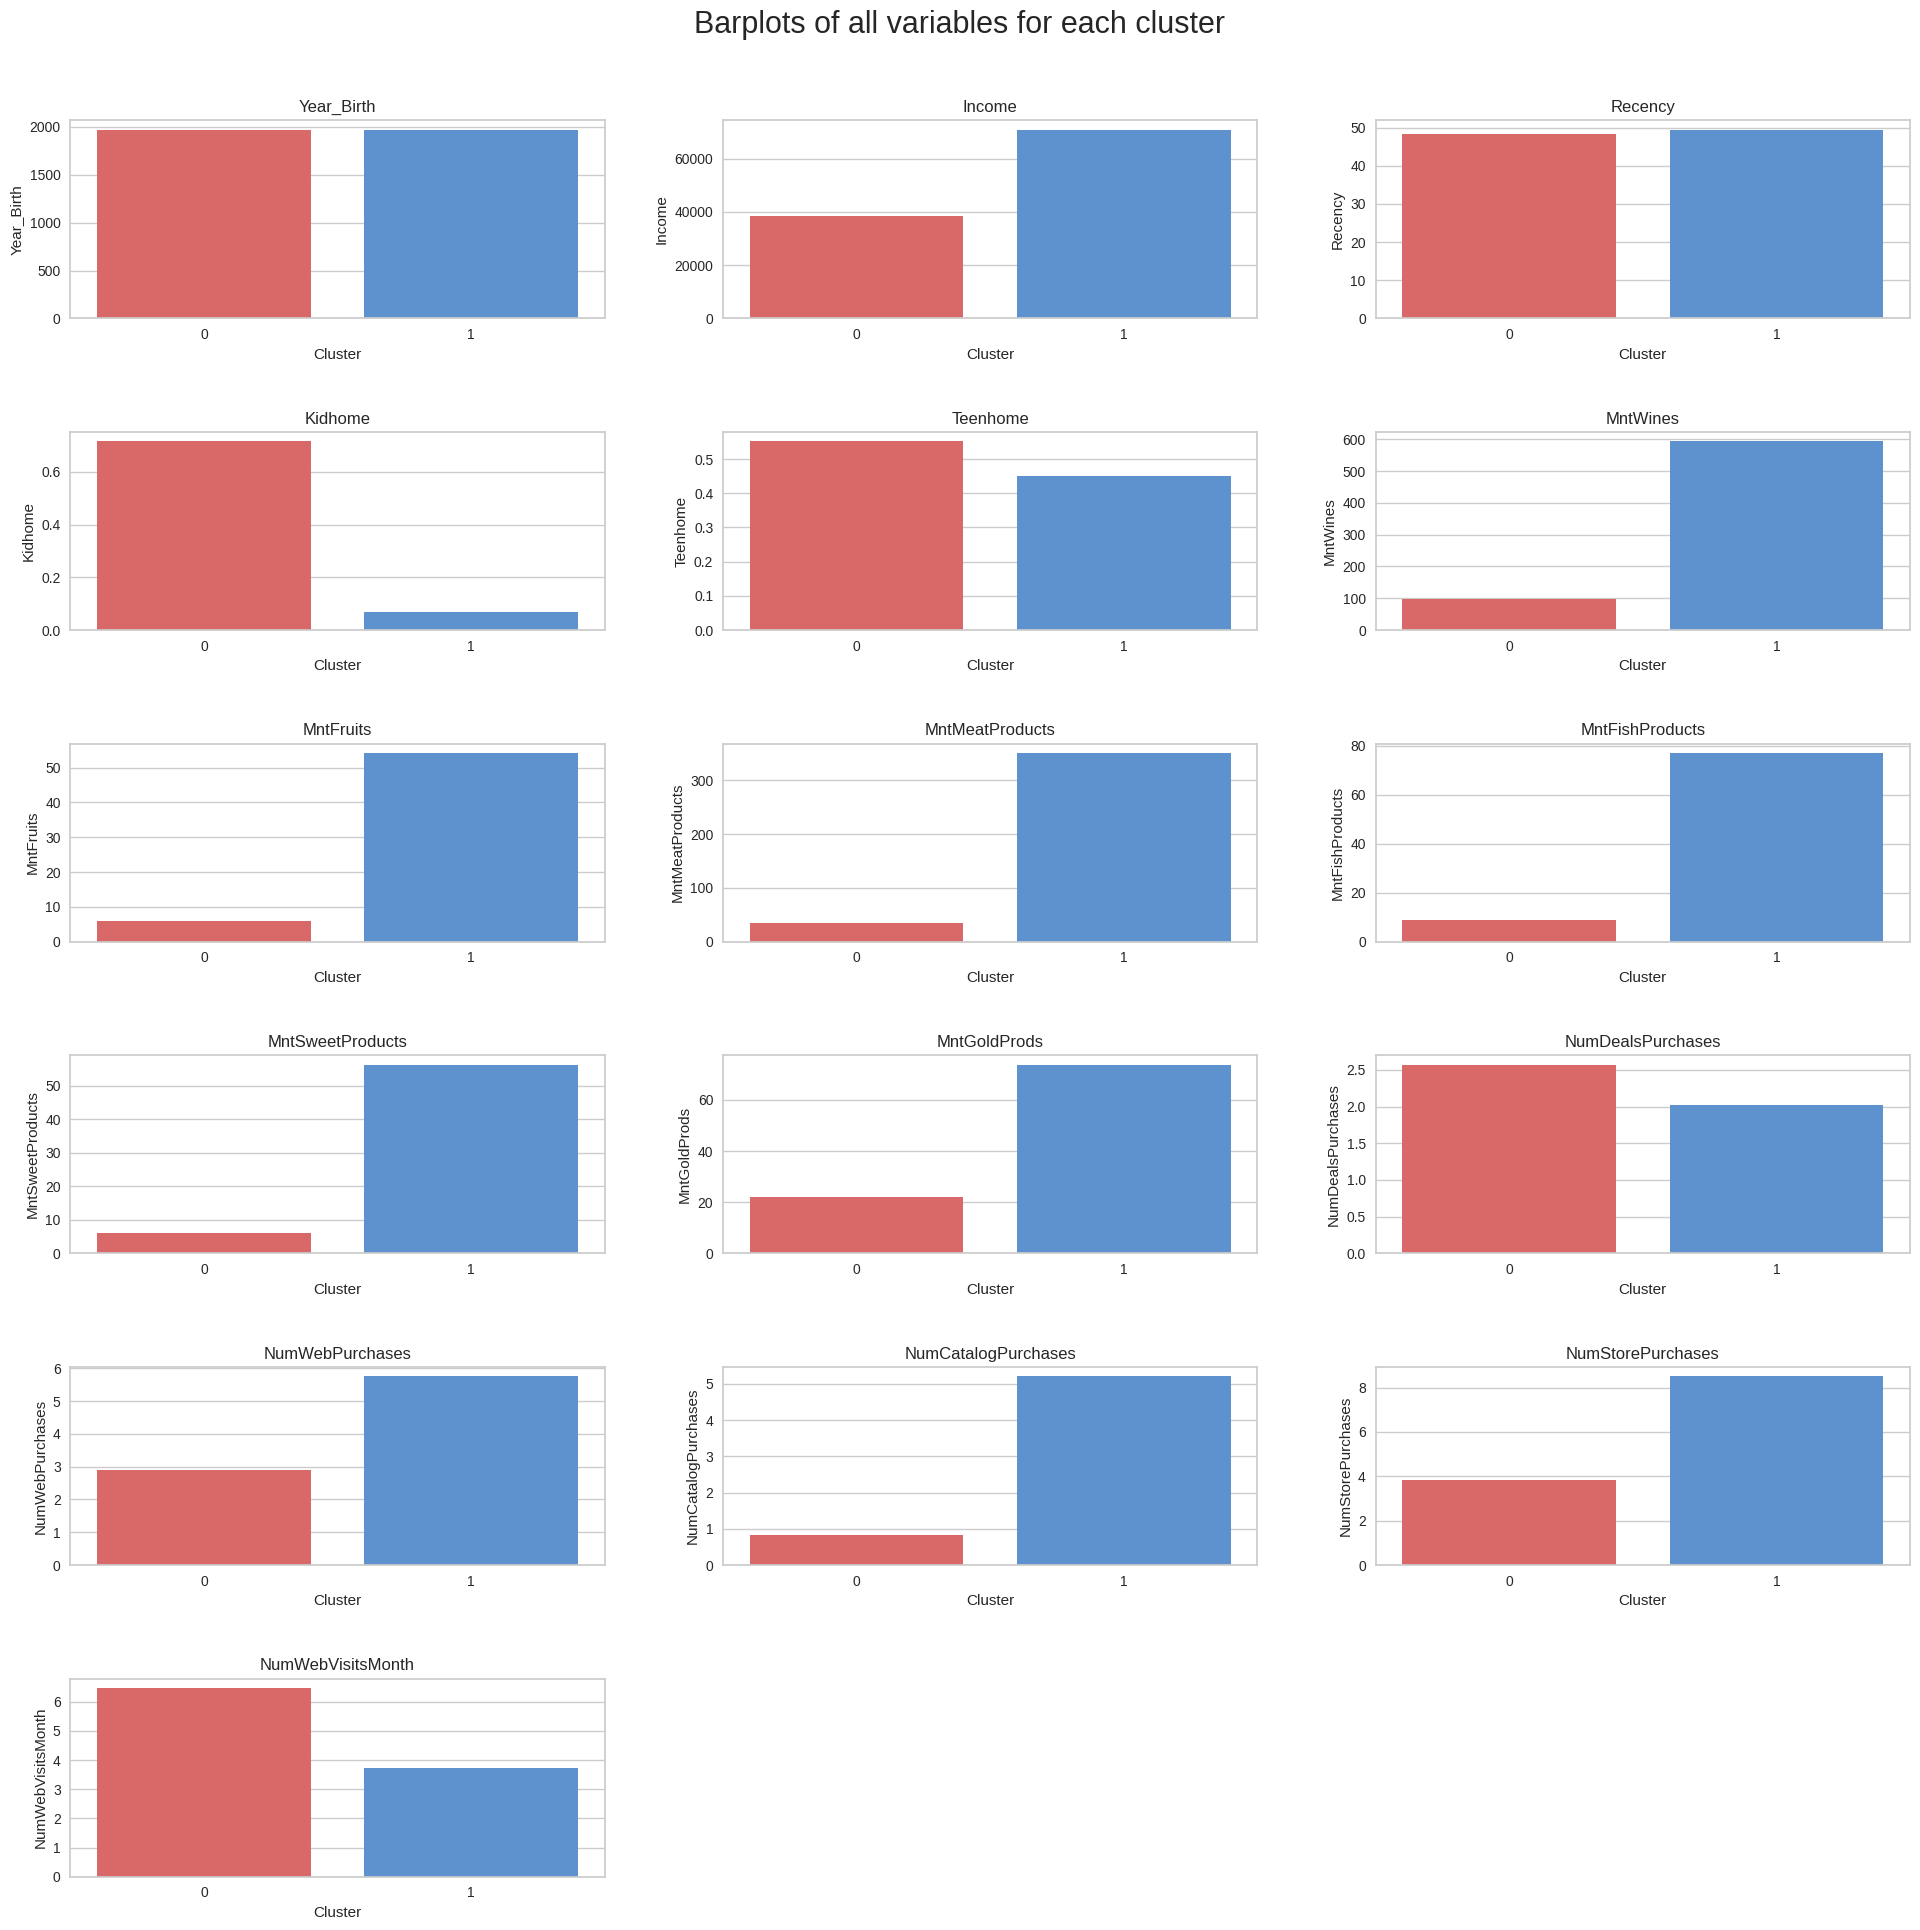

In [ ]:
#setting palatte to the same colours
palette = {
    '0': '#EC5656',
    '1': '#4A90E2'
}

plt.figure(figsize=(20, 20))  # Set the figure size for the plot
plt.suptitle("Barplots of all variables for each cluster", fontsize = 22)  #main title

for i, variable in enumerate(NumColumns):
  #setting number of rows, columns and index
    plt.subplot(6, 3, i + 1)
    #creating barplots
    sns.barplot(data=df, x='Labels', y=variable, palette=palette, errorbar=None)
    #setting barplot title
    plt.title(variable)
    #setting x axis label
    plt.xlabel('Cluster')
    #setting y axis label
    plt.ylabel(variable)

#setting the padding between graphs to 3
plt.tight_layout(pad=3.0)
plt.show()


##### **Observations:**


*  Cluster 1 has a higher income, with very few people having younger kids at home. They spend most money on Wine and Meat with nearly 1000 being spent respectively. They purchase more from the store than the catelog or web.
*  Cluster 0 tends to represent customers with young kids and an income of around 39,000. They do not spend as much on products but buy more deals and surf the web store more often.



## **Business Recommedations**

#### **Question 12**: Based on the cluster insights, what business recommendations can be provided?


**1.Develop personalized marketing campaigns to increase conversion rates.**
##### Cluster 0: Family Focused Promo
* Send personalised deals on, Kids’ products, family-sized groceries
,Baby items and school snacks.
*   Look further into web browsing but not buying - high interest but low spenders - oppertunity for conversion campaigns.

##### Cluster 1: High Income Shoppers
* Showcase premium meat cuts, fine wine, and gourmet items.


**2.Retain High-Value Customers**
*   Focus on cluster 1, have in-house wine & meat tasting to showcase the gourmet brands available for 'Premium' customers.
*   Loyalty cards for a certain amount of spending for extra perks e.g. free delivery


**3.Optimize Resource Allocation**
##### Cluster 0
*   Ensure essential items for children are available e.g. milk, nappies, lunch items etc
*   Group these essential items and school items together as these customers would have less time to shop.

##### Cluster 1
*   Group premium items (Wine, Meats, Fruits etc) together and in the main area of browsing.
*   Ensure there is plenty of stock of premium items.
* Ensure quality of the products is displayed for pricing and there is clear information.







